Scenario C — AIS async fusion + dropout  (T5)

[Run 1]  Radar + Camera + AIS

[Run 2]  Radar + Camera only

Metric                                             With AIS     No AIS
------------------------------------------------------------------------
Steady-state RMSE  (skip 5 ticks)                  3209.98m   3209.98m
RMSE during AIS dropout (60–90 s)                  2537.10m   2537.10m
RMSE after dropout re-acquisition                  4512.31m   4512.31m
NIS consistency (95% bounds)                           0.0%       0.0%
Total NIS updates accepted                                1          1
AIS updates accepted                                      0
Track initialised from AIS only                       False
------------------------------------------------------------------------
RMSE improvement from AIS : +0.00 m
RMSE improvement (dropout): +0.00 m
RMSE improvement (after)  : +0.00 m

NIS CI (with AIS, binomial 95%) : [0.0%, 97.5%]  n=1
NIS CI (no  AIS, binomial 95%) : [0.0%

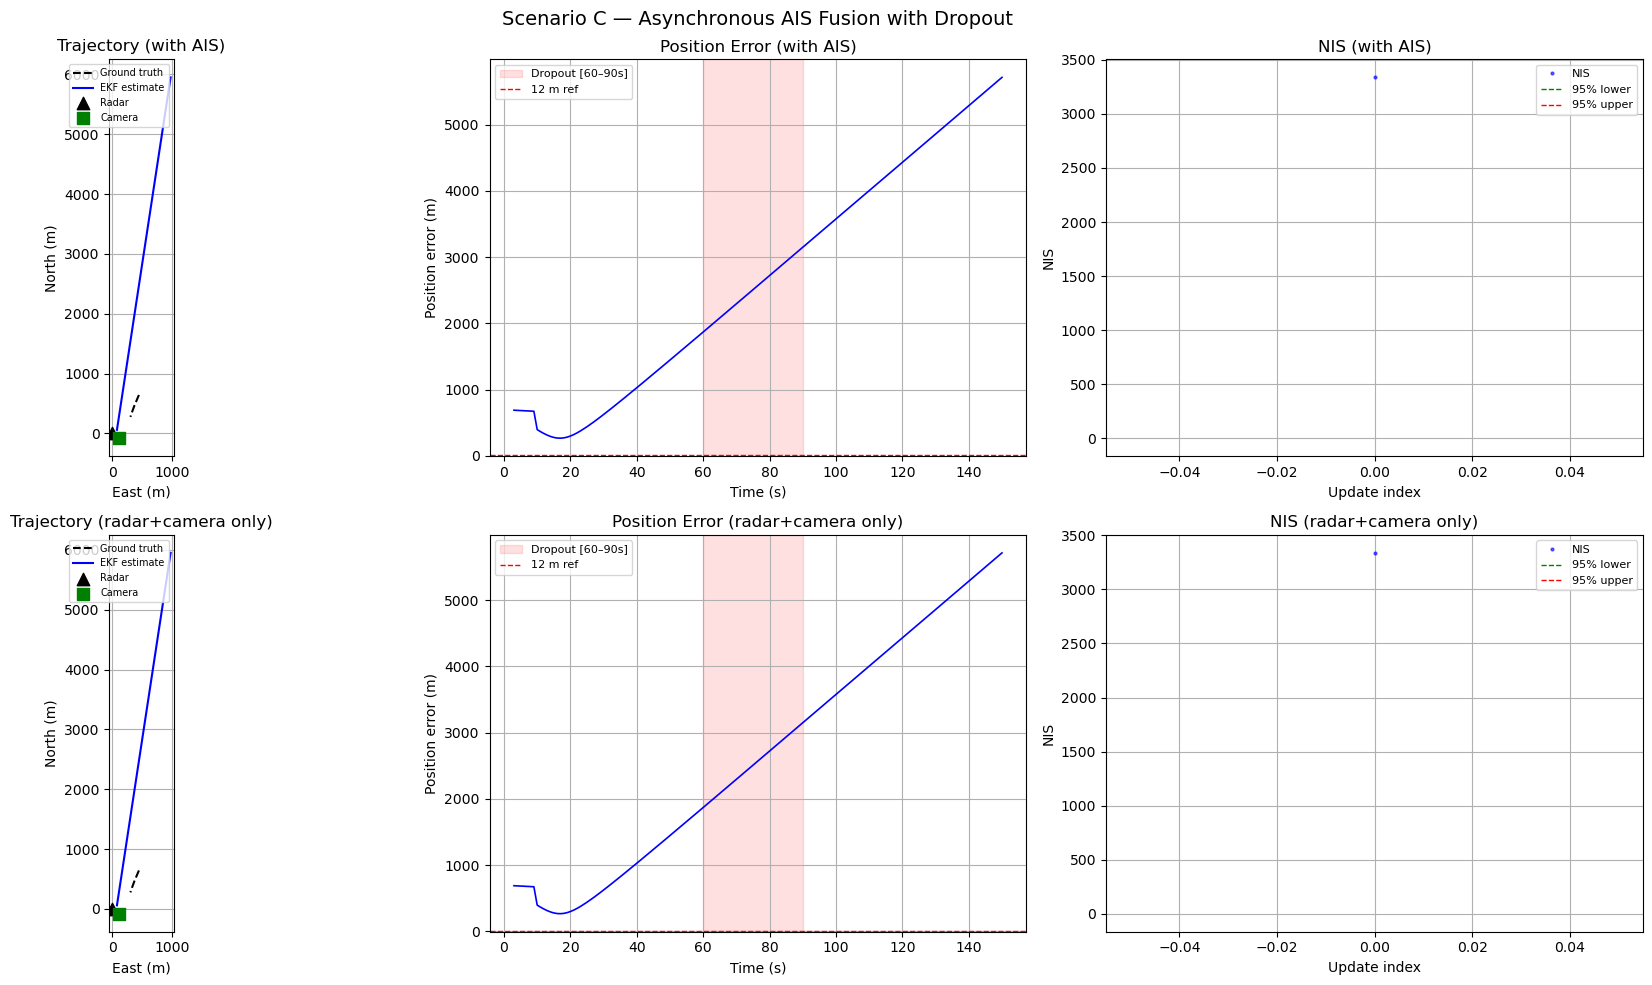


Plot saved to harbour_sim_output/scenario_C_results.png


In [ ]:
import json
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import beta, chi2

from coord_frame_manager import CoordFrameManager
from EKF import EKF

# ---------------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------------
JSON_PATH   = "harbour_sim_output/scenario_C.json"
DT          = 1.0     # Main loop tick [s] (fastest non-AIS sensor rate)
SIGMA_A     = 0.03    # Process noise std-dev [m/s²]
GATE_PROB   = 0.99    # Mahalanobis gating probability
AIS_DROPOUT = (60.0, 90.0)


# ---------------------------------------------------------------------------
# AIS polar noise covariance — the key fix vs naive isotropic R
# ---------------------------------------------------------------------------
def ais_polar_noise(cfm: CoordFrameManager, north_m: float, east_m: float) -> np.ndarray:

    vN, vE = cfm.vessel_pos
    dN = north_m - vN
    dE = east_m  - vE
    r  = np.sqrt(dN**2 + dE**2)

    if r < 1e-3:
        sigma_large = cfm.sigma_pos_ais * 1e3
        return np.diag([sigma_large**2, sigma_large**2])

    J = np.array([
        [ dN / r,    dE / r   ],
        [-dE / r**2, dN / r**2],
    ], dtype=float)

    R_cart  = cfm.sigma_pos_ais**2 * np.eye(2, dtype=float)
    R_polar = J @ R_cart @ J.T
    return R_polar


# ---------------------------------------------------------------------------
# Utility helpers
# ---------------------------------------------------------------------------
def wrap_angle(a: float) -> float:
    return float((a + np.pi) % (2 * np.pi) - np.pi)


def nis_consistency(nis_values, dof_values, alpha=0.95):
    if len(nis_values) == 0:
        return np.nan
    lo  = np.array([chi2.ppf((1 - alpha) / 2,     df=df) for df in dof_values])
    hi  = np.array([chi2.ppf(1 - (1 - alpha) / 2, df=df) for df in dof_values])
    nis = np.array(nis_values)
    return float(np.mean((nis >= lo) & (nis <= hi)))


def compute_rmse(est_pos, gt_pos, skip=5):
    e = np.linalg.norm(np.array(est_pos) - np.array(gt_pos), axis=1)
    return float(np.sqrt(np.mean(e[skip:]**2))), e


def clopper_pearson(successes, n, alpha=0.05):
    if n == 0:
        return np.nan, np.nan
    lo = 0.0 if successes == 0 else beta.ppf(alpha / 2, successes, n - successes + 1)
    hi = 1.0 if successes == n  else beta.ppf(1 - alpha / 2, successes + 1, n - successes)
    return float(lo), float(hi)


def rmse_mask(est, gt, mask):
    if np.sum(mask) == 0:
        return np.nan
    e = np.linalg.norm(est[mask] - gt[mask], axis=1)
    return float(np.sqrt(np.mean(e**2)))


# ---------------------------------------------------------------------------
# Gating helpers
# ---------------------------------------------------------------------------
def select_best_gated(ekf, cfm, sensor_id, measurements, gate_prob=GATE_PROB):
    """Radar / camera: standard polar gating."""
    gamma  = chi2.ppf(gate_prob, df=2)
    H      = cfm.H(ekf.x, sensor_id)
    R      = cfm.R(sensor_id)
    S      = H @ ekf.P @ H.T + R
    S_inv  = np.linalg.inv(S)
    z_pred = cfm.h(ekf.x, sensor_id)

    best_z, best_d2 = None, np.inf
    for m in measurements:
        z = np.array([m["range_m"], m["bearing_rad"]], dtype=float)
        if not cfm.measurement_in_fov_and_range(sensor_id, z):
            continue
        y    = z - z_pred
        y[1] = wrap_angle(y[1])
        d2   = float(y @ S_inv @ y)
        if d2 < gamma and d2 < best_d2:
            best_d2, best_z = d2, z.copy()
    return best_z, best_d2


def gate_ais(ekf, cfm, ais_meas, gate_prob=GATE_PROB):
    
    gamma   = chi2.ppf(gate_prob, df=2)
    n_m     = ais_meas["north_m"]
    e_m     = ais_meas["east_m"]
    z       = cfm.ais_ned_to_range_bearing(n_m, e_m)
    H       = cfm.H(ekf.x, "ais")
    R_polar = ais_polar_noise(cfm, n_m, e_m)           # ← propagated noise
    S       = H @ ekf.P @ H.T + R_polar
    S_inv   = np.linalg.inv(S)
    z_pred  = cfm.h(ekf.x, "ais")
    y       = z - z_pred
    y[1]    = wrap_angle(y[1])
    d2      = float(y @ S_inv @ y)
    if d2 < gamma:
        return z, d2, R_polar
    return None, np.inf, None


def ekf_update_ais(ekf, z_ais, R_polar):
    
    z    = np.asarray(z_ais, dtype=float).reshape(-1)
    h    = ekf.cfm.h(ekf.x, "ais")
    H    = ekf.cfm.H(ekf.x, "ais")
    R    = R_polar

    y    = z - h
    y[1] = wrap_angle(y[1])

    S    = H @ ekf.P @ H.T + R
    K    = ekf.P @ H.T @ np.linalg.inv(S)

    ekf.x = ekf.x + K @ y
    I     = np.eye(4, dtype=float)
    ekf.P = (I - K @ H) @ ekf.P @ (I - K @ H).T + K @ R @ K.T
    ekf.P = 0.5 * (ekf.P + ekf.P.T)

    nis = float(y.T @ np.linalg.inv(S) @ y)
    return nis


# ---------------------------------------------------------------------------
# Stacked (centralised) update for radar + camera
# ---------------------------------------------------------------------------
def ekf_update_stacked(ekf, cfm, sensors, z_list):
    h_blocks, H_blocks, R_blocks = [], [], []
    for sid, z in zip(sensors, z_list):
        h_blocks.append(cfm.h(ekf.x, sid))
        H_blocks.append(cfm.H(ekf.x, sid))
        R_blocks.append(cfm.R(sid))

    z_stack = np.concatenate(z_list)
    h_stack = np.concatenate(h_blocks)
    H_stack = np.vstack(H_blocks)
    n       = z_stack.size
    R_stack = np.zeros((n, n), dtype=float)
    off = 0
    for R in R_blocks:
        sz = R.shape[0]
        R_stack[off:off+sz, off:off+sz] = R
        off += sz

    y = z_stack - h_stack
    for k in range(1, y.size, 2):
        y[k] = wrap_angle(y[k])

    S = H_stack @ ekf.P @ H_stack.T + R_stack
    K = ekf.P @ H_stack.T @ np.linalg.inv(S)

    ekf.x = ekf.x + K @ y
    I     = np.eye(4, dtype=float)
    ekf.P = (I - K @ H_stack) @ ekf.P @ (I - K @ H_stack).T + K @ R_stack @ K.T
    ekf.P = 0.5 * (ekf.P + ekf.P.T)

    nis = float(y.T @ np.linalg.inv(S) @ y)
    return nis, int(y.size)


# ---------------------------------------------------------------------------
# AIS velocity initialisation from two consecutive AIS reports
# ---------------------------------------------------------------------------
def init_velocity_from_two_ais(m1, m2):
   
    dt = float(m2["time"]) - float(m1["time"])
    if abs(dt) < 1e-3:
        return 0.0, 0.0
    vN = (m2["north_m"] - m1["north_m"]) / dt
    vE = (m2["east_m"]  - m1["east_m"])  / dt
    return float(vN), float(vE)


# ---------------------------------------------------------------------------
# Single-tracker run
# ---------------------------------------------------------------------------
def run_tracker(data, cfm, use_ais: bool, label: str):
    t_end            = float(data["t_end"])
    gt_states        = data["ground_truth"]["0"]
    vessel_positions = data["vessel_positions"]
    measurements     = data["measurements"]

    gt_times = np.array([row[0] for row in gt_states], dtype=float)
    gt_arr   = np.array([row[1:] for row in gt_states], dtype=float)

    def get_gt(t):
        return gt_arr[np.argmin(np.abs(gt_times - t))]

    vp_times = np.array([row[0] for row in vessel_positions], dtype=float)

    def get_vessel(t):
        i = np.argmin(np.abs(vp_times - t))
        return float(vessel_positions[i][1]), float(vessel_positions[i][2])

    # Group measurements
    radar_by_t  = defaultdict(list)
    camera_by_t = defaultdict(list)
    ais_queue   = []

    for m in measurements:
        sid = m["sensor_id"]
        t_m = round(float(m["time"]), 6)
        if sid == "radar"  and m.get("range_m")  is not None:
            radar_by_t[t_m].append(m)
        elif sid == "camera" and m.get("range_m") is not None:
            camera_by_t[t_m].append(m)
        elif sid == "ais"    and m.get("north_m") is not None:
            ais_queue.append((float(m["time"]), m))

    ais_queue.sort(key=lambda x: x[0])
    ais_idx = 0

    ekf                   = EKF(cfm=cfm, sigma_a=SIGMA_A)
    initialized           = False
    init_from_ais         = False
    t_prev_main           = None
    pending_ais_for_vel   = None  # holds first AIS report for 2-point init

    times_log        = []
    est_pos_log      = []
    gt_pos_log       = []
    nis_values       = []
    dof_values       = []
    ais_update_times = []

    for t in np.arange(1.0, t_end + DT, DT):
        t = round(float(t), 6)

        vN, vE = get_vessel(t)
        cfm.update_vessel_pos(vN, vE)

        radar_meas  = radar_by_t.get(t,  [])
        camera_meas = camera_by_t.get(t, [])

        # ---- Initialisation ------------------------------------------------
        if not initialized:
            for m in radar_meas:
                z = np.array([m["range_m"], m["bearing_rad"]], dtype=float)
                if cfm.measurement_in_fov_and_range("radar", z):
                    ekf.initialize_from_measurement(z, "radar")
                    initialized = True
                    t_prev_main = t
                    break

            if not initialized:
                for m in camera_meas:
                    z = np.array([m["range_m"], m["bearing_rad"]], dtype=float)
                    if cfm.measurement_in_fov_and_range("camera", z):
                        ekf.initialize_from_measurement(z, "camera")
                        initialized = True
                        t_prev_main = t
                        break

            # AIS-only initialisation (2-point velocity estimation)
            if not initialized and use_ais:
                while ais_idx < len(ais_queue) and ais_queue[ais_idx][0] <= t:
                    t_ais, m_ais = ais_queue[ais_idx]
                    ais_idx += 1
                    vN_a, vE_a = get_vessel(t_ais)
                    cfm.update_vessel_pos(vN_a, vE_a)

                    if pending_ais_for_vel is None:
                        pending_ais_for_vel = m_ais
                    else:
                        # Two AIS reports → estimate velocity
                        vN_est, vE_est = init_velocity_from_two_ais(
                            pending_ais_for_vel, m_ais
                        )
                        z_ais = cfm.ais_ned_to_range_bearing(
                            m_ais["north_m"], m_ais["east_m"]
                        )
                        ekf.initialize_from_measurement(z_ais, "ais")
                        ekf.x[2] = vN_est
                        ekf.x[3] = vE_est
                        speed = np.sqrt(vN_est**2 + vE_est**2)
                        ekf.P[2, 2] = max(4.0, speed**2)
                        ekf.P[3, 3] = max(4.0, speed**2)
                        initialized         = True
                        init_from_ais       = True
                        t_prev_main         = t
                        pending_ais_for_vel = None
                        print(f"  [{label}] Track init from 2×AIS at t={t_ais:.1f}s "
                              f"| v=({vN_est:.2f}, {vE_est:.2f}) m/s")
                        break

            if not initialized:
                while ais_idx < len(ais_queue) and ais_queue[ais_idx][0] <= t:
                    ais_idx += 1
            continue

        # ---- Asynchronous AIS updates between ticks ------------------------
        t_last = t_prev_main

        if use_ais:
            while ais_idx < len(ais_queue) and ais_queue[ais_idx][0] <= t:
                t_ais, m_ais = ais_queue[ais_idx]
                ais_idx += 1

                dt_ais = t_ais - t_last
                if dt_ais > 1e-6:
                    ekf.predict(dt_ais)

                vN_a, vE_a = get_vessel(t_ais)
                cfm.update_vessel_pos(vN_a, vE_a)

                z_ais, d2_ais, R_polar = gate_ais(ekf, cfm, m_ais)
                if z_ais is not None:
                    nis_ais = ekf_update_ais(ekf, z_ais, R_polar)
                    nis_values.append(nis_ais)
                    dof_values.append(2)
                    ais_update_times.append(t_ais)

                t_last = t_ais

        cfm.update_vessel_pos(vN, vE)

        # ---- Main predict: t_last → t ------------------------------------
        dt_main = t - t_last
        if dt_main > 1e-6:
            ekf.predict(dt_main)
        t_prev_main = t

        # ---- Radar + camera (centralised when both available) ------------
        z_r, _ = select_best_gated(ekf, cfm, "radar",  radar_meas)
        z_c, _ = select_best_gated(ekf, cfm, "camera", camera_meas)

        sids, z_avail = [], []
        if z_r is not None:
            sids.append("radar");  z_avail.append(z_r)
        if z_c is not None:
            sids.append("camera"); z_avail.append(z_c)

        if len(z_avail) == 2:
            nis, dof = ekf_update_stacked(ekf, cfm, sids, z_avail)
            nis_values.append(nis);  dof_values.append(dof)
        elif len(z_avail) == 1:
            nis = ekf.update(z_avail[0], sids[0])
            nis_values.append(nis);  dof_values.append(2)

        times_log.append(t)
        est_pos_log.append(ekf.x[:2].copy())
        gt_pos_log.append(get_gt(t)[:2])

    return {
        "times":             np.array(times_log),
        "est_pos":           np.array(est_pos_log),
        "gt_pos":            np.array(gt_pos_log),
        "nis_values":        np.array(nis_values),
        "dof_values":        np.array(dof_values, dtype=int),
        "ais_update_times":  np.array(ais_update_times),
        "init_from_ais":     init_from_ais,
    }


# ---------------------------------------------------------------------------
# Re-acquisition analysis
# ---------------------------------------------------------------------------
def reacquisition_analysis(res, dropout_window):
   
    times  = res["times"]
    errors = np.linalg.norm(res["est_pos"] - res["gt_pos"], axis=1)
    d_lo, d_hi = dropout_window

    pre_mask  = times <  d_lo
    drop_mask = (times >= d_lo) & (times <= d_hi)
    post_mask = times >  d_hi

    print("\n  ── Re-acquisition Analysis ──────────────────────────────")

    if np.sum(pre_mask) > 0:
        e_pre = errors[pre_mask]
        print(f"  Pre-dropout  mean error           : {np.mean(e_pre):.2f} m")
        print(f"  Pre-dropout  max  error           : {np.max(e_pre):.2f} m")

    if np.sum(drop_mask) > 0:
        e_drop = errors[drop_mask]
        print(f"  During dropout mean error         : {np.mean(e_drop):.2f} m")
        print(f"  During dropout max  error         : {np.max(e_drop):.2f} m")
        print(f"  Track survived dropout            : YES (no reinitialization)")

    if np.sum(post_mask) > 0:
        e_post = errors[post_mask]
        t_post = times[post_mask]
        print(f"  Post-dropout first error          : {e_post[0]:.2f} m  (t={t_post[0]:.1f}s)")
        print(f"  Post-dropout mean error           : {np.mean(e_post):.2f} m")

        ais_after = res["ais_update_times"][res["ais_update_times"] > d_hi]
        if len(ais_after) > 0:
            t_reacq = ais_after[0]
            print(f"  First AIS re-acquisition          : t={t_reacq:.1f} s")
            spike_mask = (times > t_reacq) & (times <= t_reacq + 5.0)
            if np.sum(spike_mask) > 0:
                print(f"  Max error spike [t_reacq, +5s]   : {np.max(errors[spike_mask]):.2f} m")

        if np.sum(pre_mask) > 0:
            threshold = np.mean(errors[pre_mask]) * 1.1
            recovery  = t_post[e_post <= threshold]
            if len(recovery) > 0:
                print(f"  Recovery to pre-dropout level     : t={recovery[0]:.1f} s "
                      f"(Δt={recovery[0]-d_hi:.1f} s after dropout end)")
            else:
                print(f"  Recovery to pre-dropout level     : not reached in scenario")

    print("  ─────────────────────────────────────────────────────────")


# ---------------------------------------------------------------------------
# Plotting
# ---------------------------------------------------------------------------
def plot_results(res_with, res_without, cfm, dropout_window, out_path):
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle("Scenario C — Asynchronous AIS Fusion with Dropout", fontsize=14)

    _plot_row(axes[0], res_with,    cfm, dropout_window,
              ["Trajectory (with AIS)",         "Position Error (with AIS)",         "NIS (with AIS)"],
              show_ais_ticks=True)
    _plot_row(axes[1], res_without, cfm, dropout_window,
              ["Trajectory (radar+camera only)", "Position Error (radar+camera only)", "NIS (radar+camera only)"],
              show_ais_ticks=False)

    plt.tight_layout()
    plt.savefig(out_path, dpi=150)
    plt.show()
    print(f"\nPlot saved to {out_path}")


def _plot_row(axes, res, cfm, dropout_window, titles, show_ais_ticks):
    times   = res["times"]
    est_pos = res["est_pos"]
    gt_pos  = res["gt_pos"]
    errors  = np.linalg.norm(est_pos - gt_pos, axis=1)
    nis     = res["nis_values"]
    dof     = res["dof_values"]
    d_lo, d_hi = dropout_window

    ax = axes[0]
    ax.plot(gt_pos[:, 1],  gt_pos[:, 0],  "k--", lw=1.5, label="Ground truth")
    ax.plot(est_pos[:, 1], est_pos[:, 0], "b-",  lw=1.5, label="EKF estimate")
    ax.scatter([cfm.radar_pos[1]],  [cfm.radar_pos[0]],  c="k", marker="^", s=80, zorder=5, label="Radar")
    ax.scatter([cfm.camera_pos[1]], [cfm.camera_pos[0]], c="g", marker="s", s=80, zorder=5, label="Camera")
    if show_ais_ticks and len(res["ais_update_times"]) > 0:
        ais_idx = [np.argmin(np.abs(times - ta))
                   for ta in res["ais_update_times"]
                   if np.min(np.abs(times - ta)) < DT]
        if ais_idx:
            ap = est_pos[ais_idx]
            ax.scatter(ap[:, 1], ap[:, 0], c="orange", marker="o", s=20,
                       zorder=4, alpha=0.7, label="AIS update")
    ax.set_xlabel("East (m)"); ax.set_ylabel("North (m)")
    ax.set_title(titles[0]); ax.legend(fontsize=7); ax.grid(True); ax.set_aspect("equal")

    ax = axes[1]
    ax.plot(times, errors, "b-", lw=1.2)
    ax.axvspan(d_lo, d_hi, color="red", alpha=0.12, label=f"Dropout [{d_lo:.0f}–{d_hi:.0f}s]")
    ax.axhline(12, color="r", linestyle="--", lw=1, label="12 m ref")
    ax.set_xlabel("Time (s)"); ax.set_ylabel("Position error (m)")
    ax.set_title(titles[1]); ax.legend(fontsize=8); ax.grid(True)

    ax = axes[2]
    if len(nis) > 0:
        lo_arr = np.array([chi2.ppf(0.025, df=df) for df in dof])
        hi_arr = np.array([chi2.ppf(0.975, df=df) for df in dof])
        ax.plot(nis,    "b.", alpha=0.6, ms=4, label="NIS")
        ax.plot(lo_arr, "g--", lw=1.0, label="95% lower")
        ax.plot(hi_arr, "r--", lw=1.0, label="95% upper")
    ax.set_xlabel("Update index"); ax.set_ylabel("NIS")
    ax.set_title(titles[2]); ax.legend(fontsize=8); ax.grid(True)


# ---------------------------------------------------------------------------
# Main
# ---------------------------------------------------------------------------
def main():
    with open(JSON_PATH) as f:
        data = json.load(f)

    sensor_configs = data.get("sensor_configs", {})
    cfm_with    = CoordFrameManager(sensor_configs)
    cfm_without = CoordFrameManager(sensor_configs)

    print("=" * 72)
    print("Scenario C — AIS async fusion + dropout  (T5)")
    print("=" * 72)

    print("\n[Run 1]  Radar + Camera + AIS")
    res_with    = run_tracker(data, cfm_with,    use_ais=True,  label="WITH AIS")

    print("\n[Run 2]  Radar + Camera only")
    res_without = run_tracker(data, cfm_without, use_ais=False, label="NO AIS")

    # ---- Metrics -----------------------------------------------------------
    rmse_with,    _ = compute_rmse(res_with["est_pos"],    res_with["gt_pos"])
    rmse_without, _ = compute_rmse(res_without["est_pos"], res_without["gt_pos"])
    cons_with    = nis_consistency(res_with["nis_values"],    res_with["dof_values"])
    cons_without = nis_consistency(res_without["nis_values"], res_without["dof_values"])

    t_arr      = res_with["times"]
    mask_drop  = (t_arr >= AIS_DROPOUT[0]) & (t_arr <= AIS_DROPOUT[1])
    mask_after = t_arr > AIS_DROPOUT[1]

    rmse_w_drop   = rmse_mask(res_with["est_pos"],    res_with["gt_pos"],    mask_drop)
    rmse_wo_drop  = rmse_mask(res_without["est_pos"], res_without["gt_pos"], mask_drop)
    rmse_w_after  = rmse_mask(res_with["est_pos"],    res_with["gt_pos"],    mask_after)
    rmse_wo_after = rmse_mask(res_without["est_pos"], res_without["gt_pos"], mask_after)

    def nis_in_bounds(nis, dof):
        if len(nis) == 0:
            return 0, 0
        lo = np.array([chi2.ppf(0.025, df=df) for df in dof])
        hi = np.array([chi2.ppf(0.975, df=df) for df in dof])
        return int(np.sum((nis >= lo) & (nis <= hi))), len(nis)

    ok_w,  n_w  = nis_in_bounds(res_with["nis_values"],    res_with["dof_values"])
    ok_wo, n_wo = nis_in_bounds(res_without["nis_values"], res_without["dof_values"])
    cp_w  = clopper_pearson(ok_w,  n_w)
    cp_wo = clopper_pearson(ok_wo, n_wo)

    print("\n" + "=" * 72)
    print(f"{'Metric':<48} {'With AIS':>10} {'No AIS':>10}")
    print("-" * 72)
    print(f"{'Steady-state RMSE  (skip 5 ticks)':<48} {rmse_with:>9.2f}m {rmse_without:>9.2f}m")
    print(f"{'RMSE during AIS dropout (60–90 s)':<48} {rmse_w_drop:>9.2f}m {rmse_wo_drop:>9.2f}m")
    print(f"{'RMSE after dropout re-acquisition':<48} {rmse_w_after:>9.2f}m {rmse_wo_after:>9.2f}m")
    print(f"{'NIS consistency (95% bounds)':<48} {cons_with*100:>9.1f}% {cons_without*100:>9.1f}%")
    print(f"{'Total NIS updates accepted':<48} {n_w:>10} {n_wo:>10}")
    print(f"{'AIS updates accepted':<48} {len(res_with['ais_update_times']):>10}")
    print(f"{'Track initialised from AIS only':<48} {str(res_with['init_from_ais']):>10}")
    print("-" * 72)
    print(f"RMSE improvement from AIS : {rmse_without - rmse_with:+.2f} m")
    if not np.isnan(rmse_w_drop) and not np.isnan(rmse_wo_drop):
        print(f"RMSE improvement (dropout): {rmse_wo_drop - rmse_w_drop:+.2f} m")
    if not np.isnan(rmse_w_after) and not np.isnan(rmse_wo_after):
        print(f"RMSE improvement (after)  : {rmse_wo_after - rmse_w_after:+.2f} m")
    print(f"\nNIS CI (with AIS, binomial 95%) : [{100*cp_w[0]:.1f}%, {100*cp_w[1]:.1f}%]  n={n_w}")
    print(f"NIS CI (no  AIS, binomial 95%) : [{100*cp_wo[0]:.1f}%, {100*cp_wo[1]:.1f}%]  n={n_wo}")
    print("=" * 72)

    print("\n[With AIS]")
    reacquisition_analysis(res_with, AIS_DROPOUT)

    out_path = "harbour_sim_output/scenario_C_results.png"
    plot_results(res_with, res_without, cfm_with, AIS_DROPOUT, out_path)


if __name__ == "__main__":
    main()